# Multitag ML ranging (SVR)

Tag-to-tag ranging from the multi-frequency link phases in `link_features.csv` (built by `linkFeatures.py`).

One sample = one link (tag pair) in one experiment and one run, with its link phase $\theta_{ab}$ measured at every frequency.

**FD-PDoA.** $\theta_{ab} = \frac{2\pi f d_{ab}}{c} \bmod \pi$. After unwrapping across frequency (`np.unwrap`, `period=np.pi`),
$d_{ab} = \frac{c}{2\pi}\frac{\partial \theta_{ab}}{\partial f}$, with the slope taken from a least-squares line fit.

**SVR features** (same as `T2TExperiments/DistExperiments/ML_ranging.ipynb`): unwrapped phases, unwrap distance $d$ and $d^2$, and the slope standard error expressed as distance $SE$ and $SE^2$.
These go through a `StandardScaler` into an RBF `SVR(epsilon=0.01)`, evaluated with leave-one-experiment-out cross-validation.

The analysis is run separately for two bands, each with its own model, results and bandwidth sweep: **Band A** (775-995 MHz) and **Band B** (775-955 MHz).

In [1]:
import numpy as np
import pandas as pd
from prettytable import PrettyTable
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

C = 299792458.0  # speed of light (m/s)
FREQ, RUN = "Frequency (MHz)", "Run Exp Num"
KEYS = ["experiment", "tagA", "tagB", RUN]


def slope2dist(slope):
    # slope in rad/MHz -> distance in m:  d = c/(2*pi) * dtheta/df
    return C * slope / (2 * np.pi * 1e6)


def dist2slope(dist):
    return 2 * np.pi * 1e6 * dist / C

## Load link phases
Pivot to one row per (experiment, link, run), with one phase column per frequency.

In [2]:
df = pd.read_csv("link_features.csv")
FREQS = np.sort(df[FREQ].unique())  # MHz (815 MHz is absent from this sweep)

wide = df.pivot_table(index=KEYS, columns=FREQ, values="theta").reindex(columns=FREQS)
wide_th = df.pivot_table(index=KEYS, columns=FREQ, values="theta_theoretical").reindex(columns=FREQS)
dist = df.groupby(KEYS)["distance"].first().reindex(wide.index)
assert not wide.isna().any().any()

PHASES = wide.to_numpy()                 # wrapped measured phases (rad, [0, pi))
PHASES_TH = wide_th.to_numpy()           # wrapped theoretical phases
Y = dist.to_numpy()                      # ground-truth distance (m)
GROUPS = wide.index.get_level_values("experiment").to_numpy()
TAG_NUM = {**dict(zip(df.tagA, df.tagA_num)), **dict(zip(df.tagB, df.tagB_num))}  # tag name -> number
print(f"{len(Y)} samples, {len(FREQS)} freqs: {FREQS}")
print(pd.Series(GROUPS).value_counts().sort_index().to_dict())

1782 samples, 22 freqs: [775 785 795 805 825 835 845 855 865 875 885 895 905 915 925 935 945 955
 965 975 985 995]
{1: 198, 2: 198, 3: 198, 4: 198, 5: 198, 6: 198, 7: 198, 8: 198, 9: 198}


## Feature extraction (FD-PDoA)

In [3]:
def linefit(freqs, phases):
    # Row-wise least-squares line fit of phase vs frequency. Returns slope (rad/MHz) and its std error.
    f = freqs - freqs.mean()
    sxx = np.sum(f ** 2)
    slope = (phases - phases.mean(axis=1, keepdims=True)) @ f / sxx
    intercept = phases.mean(axis=1) - slope * freqs.mean()
    resid = phases - (intercept[:, None] + slope[:, None] * freqs[None, :])
    se = np.sqrt(np.sum(resid ** 2, axis=1) / (len(freqs) - 2) / sxx)
    return slope, se


def make_features(phases, freqs):
    # Unwrapped phases + [d_unwrap, d_unwrap^2, SE, SE^2]  (features from ML_ranging.ipynb)
    unwrapped = np.unwrap(phases/2, period=np.pi/2, axis=1)
    slope, se = linefit(freqs, unwrapped)
    d_unwrap, d_se = slope2dist(slope), slope2dist(se)
    extra = np.column_stack([d_unwrap, d_unwrap ** 2, d_se, d_se ** 2])
    return np.concatenate([unwrapped, extra], axis=1), d_unwrap, unwrapped


MAIN_FREQ = 915  # MHz, frequency whose phase refines the SVR distance (integer-K step)
PHASE_MULT = 2   # measured phase = PHASE_MULT * 2*pi*f*d/c (mod pi): unwrapped slopes give ~2x the true distance


def solve_k(dist, phase_main, main_freq=MAIN_FREQ):
    # estimateDist_K: whole phase periods K that best match dist given the phase at main_freq, and the resulting distance.
    f = main_freq * 1e6
    dist_phase = C * phase_main / (2 * np.pi * f * PHASE_MULT)  # distance within one phase period
    period = C / (2 * f * PHASE_MULT)                            # distance per pi of phase
    k = np.maximum(np.round((dist - dist_phase) / period), 0).astype(int)
    return k, dist_phase + k * period


def k_estimate(phases, freqs, dist_svr, main_freq=MAIN_FREQ):
    # Phase at main_freq from a line fit over all frequencies, then K and the K-corrected distance from the SVR distance.
    # The unwrap distance (slope of the same fit) is returned for comparison only; it is not used for K.
    unwrapped = np.unwrap(phases, period=np.pi, axis=1)
    slope, _ = linefit(freqs, unwrapped)
    intercept = unwrapped.mean(axis=1) - slope * freqs.mean()
    phase_main = np.mod(intercept + slope * main_freq, np.pi)

    dist_unwrap = slope2dist(slope) / PHASE_MULT
    k_est, dist_est_k = solve_k(dist_svr, phase_main, main_freq)
    return dist_unwrap, phase_main, k_est, dist_est_k

### SVR distance with integer-K correction
Per (link, run), from the SVR distance $d_{SVR}$ (`dist_est_svr`) and the phase at `MAIN_FREQ` (as `estimateDist_K` in `getKEstimate.m`):
- `distance_est_unwrap` (**Unwrap**, comparison only): distance from the unwrapped phase slope, $\frac{c}{2\pi M}\frac{\partial\theta}{\partial f}$. Not used for K or anywhere downstream.
- `phase_main`: phase at `MAIN_FREQ` from the line fit over all frequencies, wrapped to $[0, \pi)$.
- `k_est`: number of whole phase periods, $K = \max\left(\mathrm{round}\left(\frac{d_{SVR} - \frac{c\,\phi}{2\pi f M}}{c/(2fM)}\right), 0\right)$.
- `k_gt`: the same K formula with the ground-truth distance in place of $d_{SVR}$ (and the same measured $\phi$), i.e. the K that `k_est` should have found.
- `dist_est_k_svr` (**SVR+K**): $\frac{c\,\phi}{2\pi f M} + K\frac{c}{2fM}$.

$M$ = `PHASE_MULT` = 2: the measured phase grows as $2 \cdot \frac{2\pi f d}{c}$ (unwrapped slopes give about twice the true distance).


### Sanity check: measured vs theoretical phase
Wrapped (left) and unwrapped (right) phase for a few links. The dashed lines are $\frac{2\pi f d}{c} \bmod \pi$ computed from the ground-truth distance.

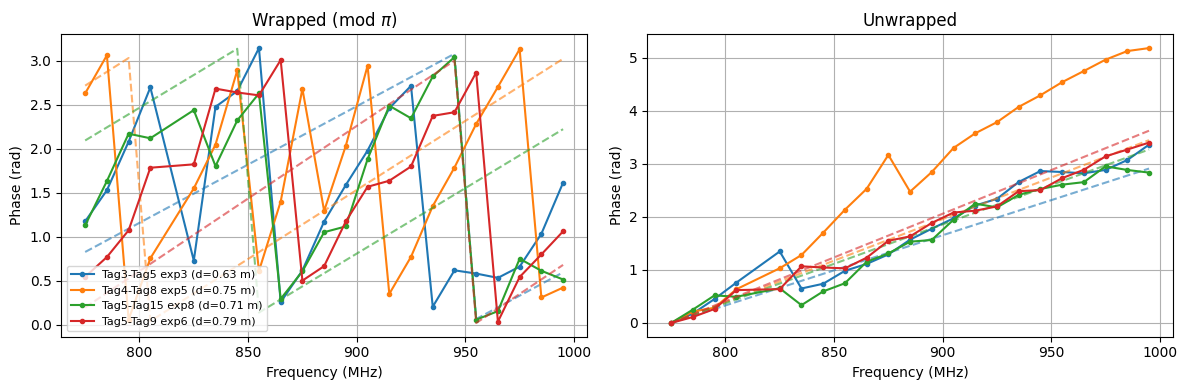

In [4]:
rng = np.random.default_rng(0)
idx = rng.choice(len(Y), 4, replace=False)
_, _, unw = make_features(PHASES, FREQS)
unw_th = np.unwrap(PHASES_TH, period=np.pi, axis=1)

fig, axs = plt.subplots(1, 2, figsize=(12, 4))
for k, i in enumerate(idx):
    lbl = f"{wide.index[i][1]}-{wide.index[i][2]} exp{wide.index[i][0]} (d={Y[i]:.2f} m)"
    axs[0].plot(FREQS, PHASES[i], ".-", color=f"C{k}", label=lbl)
    axs[0].plot(FREQS, PHASES_TH[i], "--", color=f"C{k}", alpha=0.6)
    axs[1].plot(FREQS, unw[i] - unw[i][0], ".-", color=f"C{k}")
    axs[1].plot(FREQS, unw_th[i] - unw_th[i][0], "--", color=f"C{k}", alpha=0.6)
axs[0].set_title("Wrapped (mod $\\pi$)"); axs[1].set_title("Unwrapped")
for ax in axs:
    ax.set_xlabel("Frequency (MHz)"); ax.set_ylabel("Phase (rad)"); ax.grid()
axs[0].legend(fontsize=8)
plt.tight_layout(); plt.show()

## Model and leave-one-experiment-out cross-validation

In [5]:
MODEL_NAME = "SVR"
MIN_DIST = 0.1  # m, lower bound on predicted distance
# Table/plot label -> column of the estimates table (the same columns are saved to distance_estimates.csv)
METHODS = {MODEL_NAME: "dist_est_svr", "SVR+K": "dist_est_k_svr", "Unwrap": "distance_est_unwrap"}  # Unwrap: comparison only


def make_model():
    return make_pipeline(StandardScaler(), SVR(kernel="rbf", epsilon=0.01))


def cross_validate(phases, y, groups, freqs):
    # Train on all experiments but one, test on the held-out experiment.
    X, _, _ = make_features(phases, freqs)
    y_pred = np.zeros_like(y)
    for g in np.unique(groups):
        test = groups == g
        model = make_model().fit(X[~test], y[~test])
        y_pred[test] = np.maximum(model.predict(X[test]), MIN_DIST)
    return y_pred


def run_band(phases, freqs, band):
    # Every estimate for one band, one row per (experiment, link, run). All tables, plots and saved files use this.
    dist_svr = cross_validate(phases, Y, GROUPS, freqs)
    dist_unwrap, phase_main, k_est, dist_est_k = k_estimate(phases, freqs, dist_svr)
    keys = wide.index.to_frame(index=False)
    return pd.DataFrame({
        "experiment": keys["experiment"], "band (MHz)": band,
        "tagA": keys["tagA"], "tagB": keys["tagB"],
        "tagA_num": keys["tagA"].map(TAG_NUM), "tagB_num": keys["tagB"].map(TAG_NUM),
        "run": keys[RUN], "distance": Y,
        "dist_est_svr": dist_svr, "phase_main": phase_main, "k_est": k_est, "k_gt": solve_k(Y, phase_main)[0],
        "dist_est_k_svr": dist_est_k, "distance_est_unwrap": dist_unwrap,
    })


def abs_err(res, method):
    return np.abs(res[METHODS[method]] - res["distance"]).to_numpy()


def stats(ae):
    return {"mean": np.mean(ae), "median": np.median(ae), "p80": np.percentile(ae, 80), "p90": np.percentile(ae, 90)}

### Training / testing sets
Each fold holds out one whole experiment, so every run of a test link stays out of training. These counts are recomputed from the data, so they update when new experiments are added.

In [6]:
experiments = np.unique(GROUPS)
links = wide.index.droplevel(RUN).unique()
n_runs = wide.index.get_level_values(RUN).nunique()
print(f"{len(Y)} samples = {len(links)} links (summed over experiments) x {n_runs} runs, "
      f"from {len(experiments)} experiments -> {len(experiments)} folds")
print(f"Each sample: {len(FREQS)} phases (775-995 MHz band) / {np.sum(FREQS <= 955)} phases (775-955 MHz band) + 4 FD-PDoA features\n")

split = pd.DataFrame([{
    "test experiment": g,
    "train samples": int(np.sum(GROUPS != g)),
    "test samples": int(np.sum(GROUPS == g)),
    "train experiments": int(len(experiments) - 1),
    "test links": int(len(links[links.get_level_values("experiment") == g])),
} for g in experiments]).set_index("test experiment")
split

1782 samples = 594 links (summed over experiments) x 3 runs, from 9 experiments -> 9 folds
Each sample: 22 phases (775-995 MHz band) / 18 phases (775-955 MHz band) + 4 FD-PDoA features



,train samples,test samples,train experiments,test links
test experiment,,,,
1,1584,198,8,66
2,1584,198,8,66
3,1584,198,8,66
4,1584,198,8,66
5,1584,198,8,66
6,1584,198,8,66
7,1584,198,8,66
8,1584,198,8,66
9,1584,198,8,66


### Plot helpers

In [7]:
COLORS = {MODEL_NAME: "C0", "SVR+K": "C2", "Unwrap": "C1"}


def results_table(res, band):
    # Overall abs error (cm): Method | Mean | Median | 90th percentile
    t = PrettyTable(["Method", "Mean", "Median", "90th percentile"], align="l")
    t.title = f"Results {band} MHz (all {len(np.unique(GROUPS))} held-out experiments combined)"
    for name in METHODS:
        ae = abs_err(res, name)
        t.add_row([name, *[f"{v * 100:.1f} cm" for v in (np.mean(ae), np.median(ae), np.percentile(ae, 90))]])
    print(t)


def per_experiment_table(res):
    rows = []
    for g in list(np.unique(GROUPS)) + ["All"]:
        m = np.ones(len(res), bool) if g == "All" else (res["experiment"] == g).to_numpy()
        for name in METHODS:
            rows.append({"experiment": g, "method": name, "n test": int(m.sum()), **stats(abs_err(res, name)[m] * 100)})
    return pd.DataFrame(rows).set_index(["experiment", "method"]).round(1)  # cm


def plot_cdf_scatter(res, band):
    fig, axs = plt.subplots(1, 2, figsize=(12, 4.5))
    for name, col in METHODS.items():
        e = np.sort(abs_err(res, name)) * 100
        axs[0].plot(e, np.arange(1, len(e) + 1) / len(e), ".-", markersize=1, color=COLORS[name], label=name)
        axs[1].scatter(res["distance"], res[col], s=4, alpha=0.4, color=COLORS[name], label=name)
    axs[0].set_xlim(0, 150); axs[0].set_xlabel("Abs ranging error (cm)"); axs[0].set_ylabel("CDF")
    lim = [0, max(res["distance"].max(), 2)]
    axs[1].plot(lim, lim, "k--", lw=1)
    axs[1].set_ylim(-0.5, 3); axs[1].set_xlabel("True distance (m)"); axs[1].set_ylabel("Estimated distance (m)")
    for ax in axs:
        ax.grid(); ax.legend()
    fig.suptitle(f"{band} MHz")
    plt.tight_layout(); plt.show()


def plot_error_vs_distance(res, band):
    # Same buckets as ML_ranging.ipynb: 0.0-0.4, ..., 1.6-2.0 m (right edge inclusive)
    bins = np.round(np.arange(0, 2.01, 0.4), 1)
    which = np.digitize(res["distance"], bins, right=True) - 1
    names = list(METHODS)
    boxes, colors, method_ticks, range_ticks = [], [], [], []
    for b in range(len(bins) - 1):
        m = which == b
        for name in names:
            boxes.append(abs_err(res, name)[m] * 100)
            colors.append(COLORS[name])
            method_ticks.append(name)
        range_ticks.append(f"\n\n{bins[b]:.1f}-{bins[b + 1]:.1f}\n(n={m.sum()})")

    k = len(names)
    fig, ax = plt.subplots(figsize=(14, 3))
    bp = ax.boxplot(boxes, sym="", patch_artist=True)
    for i, color in enumerate(colors):
        bp["boxes"][i].set(fill=False, edgecolor=color, linewidth=2)
        bp["medians"][i].set(color=color, linewidth=2)
        for part in ("whiskers", "caps"):
            for line in bp[part][2 * i:2 * i + 2]:
                line.set(color=color, linewidth=2)
    ax.set_xticks(np.arange(1, len(boxes) + 1), method_ticks, fontsize=8)
    sec = ax.secondary_xaxis(location=0)
    sec.set_xticks(np.arange(1, len(boxes) + 1, k) + (k - 1) / 2, labels=range_ticks)
    sec.tick_params("x", length=0)
    sec.set_xlabel("Distance ranges (m)")
    sep = ax.secondary_xaxis(location=0)
    sep.set_xticks(np.arange(0.5, len(boxes) + 1, k), labels=[])
    sep.tick_params("x", length=40, width=1.5)
    ax.set_ylabel("Abs ranging error (cm)"); ax.set_title(f"{band} MHz"); ax.grid()
    plt.show()


def plot_k_error_hist(res, band):
    # Integer K error of SVR+K: k_gt - k_est (0 = right phase period; +-1 = off by one wavelength/M)
    dk = (res["k_gt"] - res["k_est"]).to_numpy().astype(int)
    vals = np.arange(dk.min(), dk.max() + 1)
    counts = np.array([np.sum(dk == v) for v in vals])
    fig, ax = plt.subplots(figsize=(10, 3.5))
    ax.bar(vals, counts, width=0.8, color=COLORS["SVR+K"])
    for v, n in zip(vals, counts):
        if n / len(dk) >= 0.01:
            ax.text(v, n, f"{n / len(dk) * 100:.0f}%", ha="center", va="bottom", fontsize=8)
    ax.set_xticks(vals); ax.margins(y=0.1)
    ax.set_xlabel(r"$K_{gt} - K_{SVR}$"); ax.set_ylabel("Count")
    ax.set_title(f"{band} MHz (n={len(dk)}, K correct: {np.mean(dk == 0) * 100:.1f}%)"); ax.grid(axis="y")
    plt.tight_layout(); plt.show()


def centered_freq_idx(n, freqs, center_mhz=915):
    c = int(np.argmin(np.abs(freqs - center_mhz)))
    start = min(max(c - n // 2, 0), len(freqs) - n)
    return np.arange(start, start + n)


def bandwidth_sweep(phases, freqs, band):
    # Fewer frequencies centered on 915 MHz (as in ML_ranging.ipynb), within this band only.
    counts = [n for n in [3, 6, 9, 12, 15, 18] if n < len(freqs)] + [len(freqs)]
    rows, ae_by_n = [], {}
    for n in counts:
        sel = centered_freq_idx(n, freqs)
        res = run_band(phases[:, sel], freqs[sel], band)
        ae_by_n[n] = abs_err(res, MODEL_NAME) * 100
        rows.append({"#freqs": n, "band (MHz)": f"{freqs[sel][0]}-{freqs[sel][-1]}",
                     **{f"{name} {k}": v for name in METHODS for k, v in stats(abs_err(res, name) * 100).items()}})
    display(pd.DataFrame(rows).set_index("#freqs").round(1))  # cm

    plt.figure(figsize=(10, 3))
    plt.boxplot(list(ae_by_n.values()), sym="")
    plt.xticks(np.arange(1, len(ae_by_n) + 1),
               [f"{freqs[centered_freq_idx(n, freqs)][-1] - freqs[centered_freq_idx(n, freqs)][0]}" for n in ae_by_n])
    plt.xlabel("Bandwidth (MHz)"); plt.ylabel("Abs error (cm)"); plt.title(f"{MODEL_NAME}, sub-bands of {band} MHz"); plt.grid()
    plt.show()

### Save estimates
`<experiment>/distance_estimates.csv` is written from the same per-band estimates table (`res_A`, `res_B`) that the tables and plots use: one row per band, link and run with the ground truth `distance` and every estimate (`dist_est_svr`, `phase_main`, `k_est`, `k_gt`, `dist_est_k_svr`, and `distance_est_unwrap` for comparison).

In [8]:
def save_estimates(results, root="."):
    out = pd.concat(results, ignore_index=True)
    out = out.sort_values(["experiment", "tagA_num", "tagB_num"], kind="stable", ignore_index=True)
    for g, d in out.groupby("experiment"):
        path = f"{root}/{g}/distance_estimates.csv"
        d.drop(columns="experiment").to_csv(path, index=False, float_format="%.4f")
        print(f"saved {path}")

# Band A: 775-995 MHz
Model trained and tested only on frequencies 775-995 MHz.

In [9]:
SEL_A = FREQS <= 995
FREQS_A, PHASES_A = FREQS[SEL_A], PHASES[:, SEL_A]
print(f"{len(FREQS_A)} freqs: {FREQS_A}")
res_A = run_band(PHASES_A, FREQS_A, "775-995")
results_table(res_A, "775-995")

22 freqs: [775 785 795 805 825 835 845 855 865 875 885 895 905 915 925 935 945 955
 965 975 985 995]
+-----------------------------------------------------------+
| Results 775-995 MHz (all 9 held-out experiments combined) |
+----------+-----------+-----------+------------------------+
| Method   | Mean      | Median    | 90th percentile        |
+----------+-----------+-----------+------------------------+
| SVR      | 13.9 cm   | 8.3 cm    | 34.3 cm                |
| SVR+K    | 14.0 cm   | 8.7 cm    | 33.5 cm                |
| Unwrap   | 23.7 cm   | 15.4 cm   | 56.5 cm                |
+----------+-----------+-----------+------------------------+


In [10]:
per_experiment_table(res_A)  # abs error in cm

n test  mean  median   p80   p90
experiment method                                  
1          SVR        198  15.3     8.5  23.3  41.4
           SVR+K      198  15.3     9.2  24.0  42.0
           Unwrap     198  22.5    14.9  36.1  52.6
2          SVR        198  17.7    11.0  29.4  40.4
           SVR+K      198  17.3    11.2  27.7  42.2
           Unwrap     198  25.9    16.4  39.4  66.5
3          SVR        198  14.6     8.6  21.6  33.9
           SVR+K      198  14.6     9.1  22.4  35.0
           Unwrap     198  22.6    15.6  33.5  49.7
4          SVR        198  13.9     7.9  21.4  29.4
           SVR+K      198  13.8     8.2  20.5  29.6
           Unwrap     198  27.4    16.8  38.0  58.7
5          SVR        198  12.9     8.4  20.7  28.3
           SVR+K      198  13.1     8.3  20.9  28.4
           Unwrap     198  24.5    14.9  41.5  59.4
6          SVR        198  13.6     8.0  18.8  39.0
           SVR+K      198  13.6     8.9  19.0  39.7
           Unwrap     198  22.2    13.7  33.9  47.0
7          SVR        198  13.4     7.7  20.8  29.3
           SVR+K      198  13.7     7.6  20.9  29.6
           Unwrap     198  25.6    17.2  42.1  63.8
8          SVR        198  12.0     8.0  16.5  25.4
           SVR+K      198  12.1     7.6  17.4  27.2
           Unwrap     198  19.7    13.9  27.3  46.3
9          SVR        198  12.1     6.8  19.5  26.6
           SVR+K      198  12.4     7.9  21.1  28.3
           Unwrap     198  22.5    15.2  26.7  53.4
All        SVR       1782  13.9     8.3  21.4  34.3
           SVR+K     1782  14.0     8.7  21.7  33.5
           Unwrap    1782  23.7    15.4  36.3  56.5

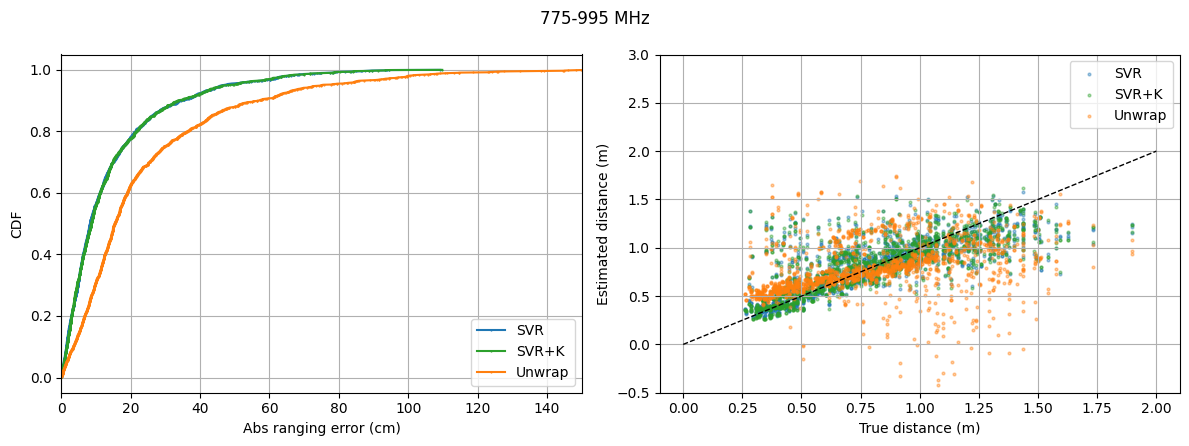

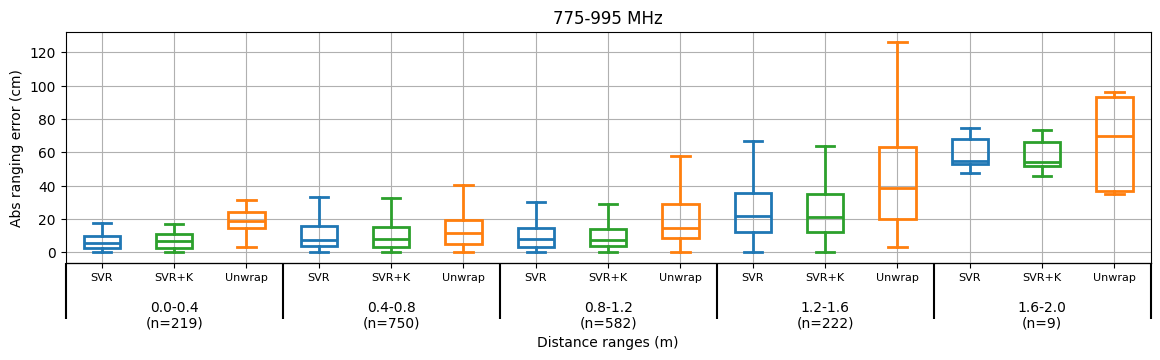

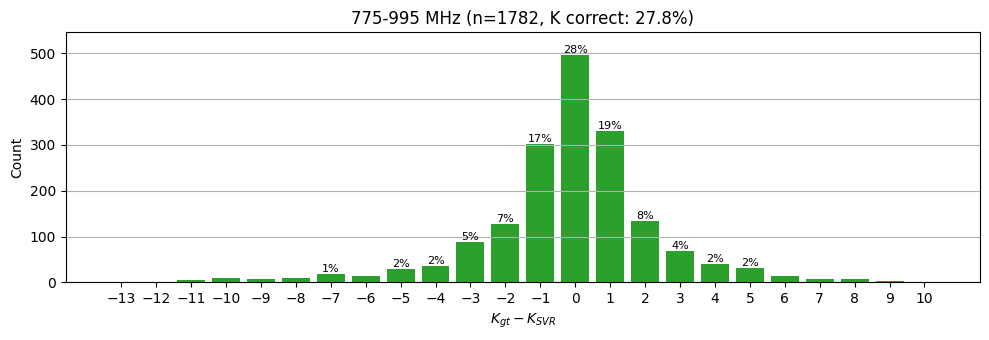

In [11]:
plot_cdf_scatter(res_A, "775-995")
plot_error_vs_distance(res_A, "775-995")
plot_k_error_hist(res_A, "775-995")

### Bandwidth sweep (775-995 MHz)

,band (MHz),SVR mean,SVR median,SVR p80,SVR p90,SVR+K mean,SVR+K median,SVR+K p80,SVR+K p90,Unwrap mean,Unwrap median,Unwrap p80,Unwrap p90
#freqs,,,,,,,,,,,,,
3,905-925,22.1,17.6,35.5,48.5,22.2,17.7,36.3,48.8,53.0,36.9,78.9,120.0
6,885-935,19.3,14.3,30.3,45.2,19.4,14.8,29.9,44.6,34.8,22.7,48.6,81.7
9,875-955,17.5,12.4,27.2,37.4,17.6,12.6,27.4,37.4,28.0,18.9,38.9,62.9
12,855-965,17.1,12.3,27.1,38.7,17.2,12.8,27.5,38.3,26.0,18.0,36.5,58.6
15,845-985,15.8,10.9,24.7,36.3,15.8,10.6,24.5,36.0,24.0,16.4,33.2,52.3
18,825-995,15.1,9.4,24.3,36.4,15.3,9.3,24.5,37.3,23.1,15.6,32.1,48.5
22,775-995,13.9,8.3,21.4,34.3,14.0,8.7,21.7,33.5,23.7,15.4,36.3,56.5


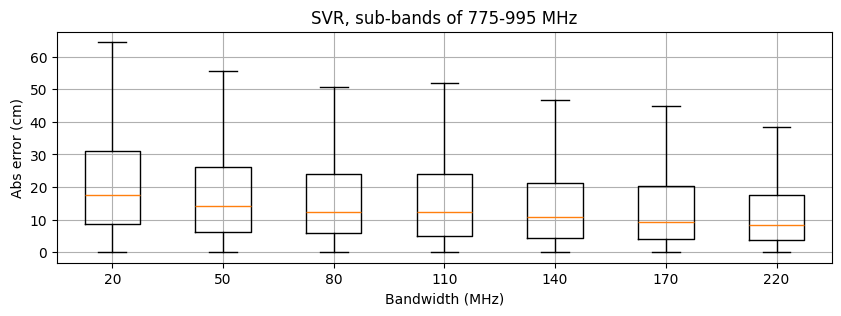

In [12]:
bandwidth_sweep(PHASES_A, FREQS_A, "775-995")

# Band B: 775-955 MHz
Model trained and tested only on frequencies 775-955 MHz.

In [13]:
SEL_B = FREQS <= 955
FREQS_B, PHASES_B = FREQS[SEL_B], PHASES[:, SEL_B]
print(f"{len(FREQS_B)} freqs: {FREQS_B}")
res_B = run_band(PHASES_B, FREQS_B, "775-955")
results_table(res_B, "775-955")

18 freqs: [775 785 795 805 825 835 845 855 865 875 885 895 905 915 925 935 945 955]
+-----------------------------------------------------------+
| Results 775-955 MHz (all 9 held-out experiments combined) |
+----------+-----------+-----------+------------------------+
| Method   | Mean      | Median    | 90th percentile        |
+----------+-----------+-----------+------------------------+
| SVR      | 15.0 cm   | 9.7 cm    | 34.3 cm                |
| SVR+K    | 15.2 cm   | 9.9 cm    | 34.8 cm                |
| Unwrap   | 25.8 cm   | 16.7 cm   | 58.7 cm                |
+----------+-----------+-----------+------------------------+


In [14]:
per_experiment_table(res_B)  # abs error in cm

n test  mean  median   p80   p90
experiment method                                  
1          SVR        198  16.4     9.8  25.2  39.7
           SVR+K      198  16.6    10.7  25.1  38.3
           Unwrap     198  24.2    16.1  40.6  54.2
2          SVR        198  18.4    10.0  33.3  45.0
           SVR+K      198  19.1    10.9  34.3  45.8
           Unwrap     198  28.5    16.3  49.5  74.1
3          SVR        198  16.6    11.6  23.6  37.6
           SVR+K      198  16.6    11.4  22.8  35.8
           Unwrap     198  25.6    16.6  39.6  58.9
4          SVR        198  15.7    11.1  24.6  35.7
           SVR+K      198  15.7    10.5  24.3  37.7
           Unwrap     198  29.9    19.1  42.9  59.8
5          SVR        198  13.5     9.5  20.7  32.5
           SVR+K      198  14.1     9.8  22.0  30.1
           Unwrap     198  27.1    15.3  49.0  58.4
6          SVR        198  14.5    10.0  19.6  33.7
           SVR+K      198  14.5    10.6  20.8  31.7
           Unwrap     198  24.1    16.1  38.9  54.6
7          SVR        198  14.0     8.8  22.4  30.6
           SVR+K      198  14.1     8.8  21.8  30.4
           Unwrap     198  28.1    18.2  47.2  68.6
8          SVR        198  12.3     7.5  17.5  31.8
           SVR+K      198  12.3     7.6  18.0  33.3
           Unwrap     198  21.2    14.3  32.4  45.2
9          SVR        198  13.8     9.1  21.2  28.1
           SVR+K      198  14.0     9.1  22.3  29.6
           Unwrap     198  23.9    16.8  32.2  55.5
All        SVR       1782  15.0     9.7  23.2  34.3
           SVR+K     1782  15.2     9.9  22.9  34.8
           Unwrap    1782  25.8    16.7  42.2  58.7

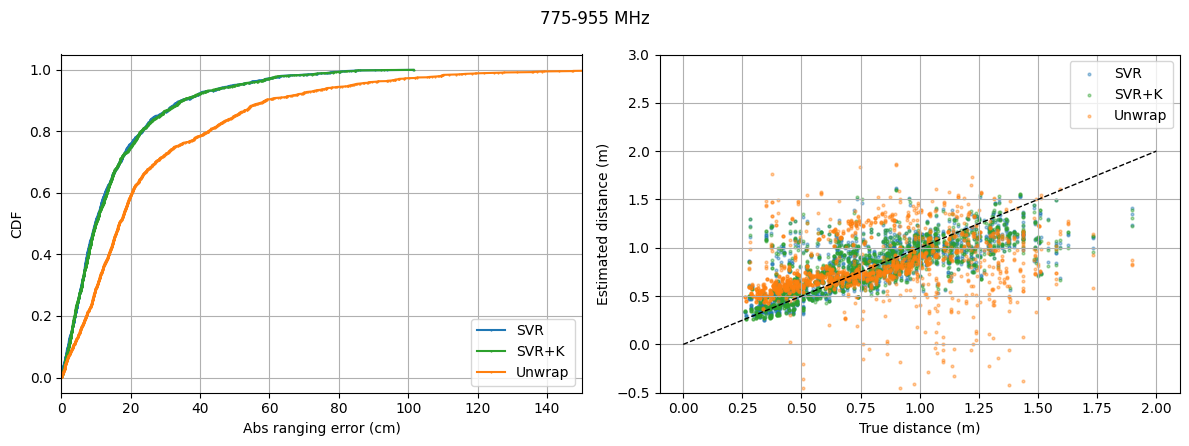

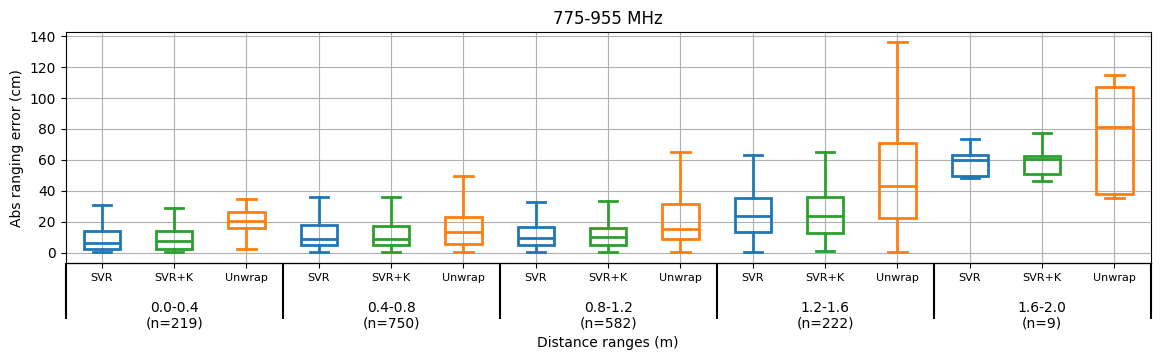

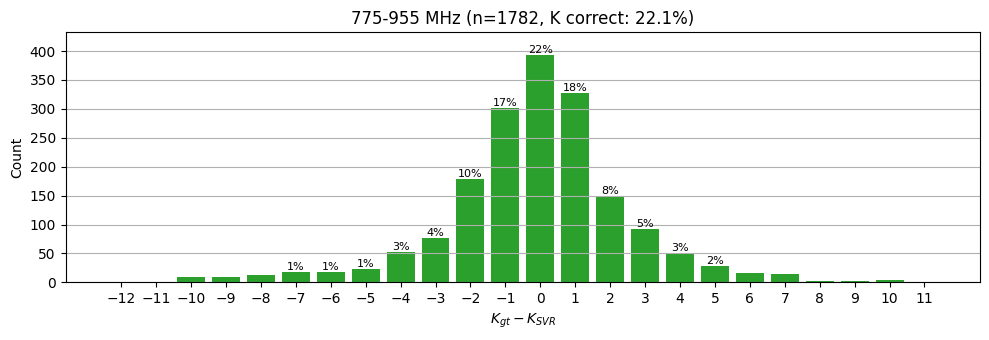

In [15]:
plot_cdf_scatter(res_B, "775-955")
plot_error_vs_distance(res_B, "775-955")
plot_k_error_hist(res_B, "775-955")

### Bandwidth sweep (775-955 MHz)

,band (MHz),SVR mean,SVR median,SVR p80,SVR p90,SVR+K mean,SVR+K median,SVR+K p80,SVR+K p90,Unwrap mean,Unwrap median,Unwrap p80,Unwrap p90
#freqs,,,,,,,,,,,,,
3,905-925,22.1,17.6,35.5,48.5,22.2,17.7,36.3,48.8,53.0,36.9,78.9,120.0
6,885-935,19.3,14.3,30.3,45.2,19.4,14.8,29.9,44.6,34.8,22.7,48.6,81.7
9,875-955,17.5,12.4,27.2,37.4,17.6,12.6,27.4,37.4,28.0,18.9,38.9,62.9
12,845-955,17.2,12.4,26.7,38.2,17.3,12.9,27.2,38.7,26.9,18.8,38.4,59.3
15,805-955,15.6,11.2,24.2,35.6,15.8,11.3,25.0,36.0,26.4,18.6,38.3,55.0
18,775-955,15.0,9.7,23.2,34.3,15.2,9.9,22.9,34.8,25.8,16.7,42.2,58.7


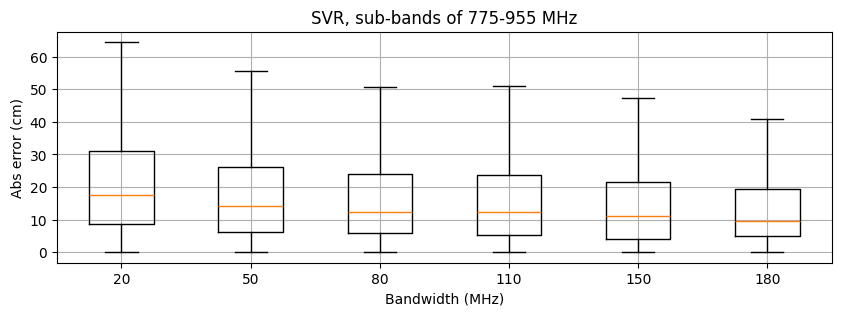

In [16]:
bandwidth_sweep(PHASES_B, FREQS_B, "775-955")

# Save all estimates
One `distance_estimates.csv` per experiment folder with both bands (see *Save estimates* above).

In [17]:
save_estimates([res_A, res_B])

saved ./1/distance_estimates.csv
saved ./2/distance_estimates.csv
saved ./3/distance_estimates.csv
saved ./4/distance_estimates.csv
saved ./5/distance_estimates.csv
saved ./6/distance_estimates.csv
saved ./7/distance_estimates.csv
saved ./8/distance_estimates.csv
saved ./9/distance_estimates.csv
